<a href="https://colab.research.google.com/github/fewilliams/STAT-7220-Applied-Experimental-Design/blob/Assignment-1/Williams_Applied_Experimental_Design__HW_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Homework 1: Completely Randomized Designs
## Dr. Austin R. Brown
### School of Data Science & Analytics
### Kennesaw State University
import pandas as pd

df = pd.read_excel("IPA.xlsx")
df.head()

**DUE: February 6, 2026**

**INSTRUCTIONS:** You are a quality control analyst for a craft brewery experimenting with a new India Pale Ale (IPA). One key quality attribute of IPA is its bitterness, measured in International Bitterness Units (IBUs). The brewery wants to determine if the aging time (3, 4, or 5 weeks) affects the IBUs of the beer. To test this, the brewing team brews a single batch of the experimental IPA and divides it into aging tanks, with each tank randomly assigned to be aged for 3, 4, or 5 weeks. After aging, the IBUs of ten randomly selected bottles from each aging time are measured using a spectrophotometer. The data are in the file `IPA.xlsx`. With these data, I want you to:

**Question 1.** Briefly define the objective of this experiment


The objective of this experiment is to determine whether the aging time (3, 4, or 5 weeks) affects the bitterness (IBUs) of an experimental India Pale Ale (IPA).

**Question 2.** Specify the outcome variable

The outcome (dependent) variable is International Bitterness Units (IBUs), which is a quantitative measurement of beer bitterness.


**Question 3.** Specify the independent variable. What are some possible lurking variables?


The independent variable is aging time, measured in weeks (3, 4, and 5 weeks).


**Question 4.** Briefly explain why a completely randomized design may be appropriate for this experiment.


A completely randomized design is appropriate because the beer originates from a single batch, and aging time is the only factor of interest.



**Question 5.** State the null and alternative hypotheses for this experiment.


Null hypothesis (H₀): μ₃ = μ₄ = μ₅

Alternative hypothesis (Hₐ): At least one mean IBU differs among the aging times.


**Question 6.** Perform appropriate exploratory analysis, including summary statistics **and** data visualizations. Do the results of these analyses support the null or alternative hypothesis more strongly?


Beer aged for 3 weeks has noticeably lower average bitterness compared to beer aged for 4 and 5 weeks. These exploratory analyses suggest stronger support for the alternative hypothesis, as the IBUs do not appear equal across aging times.




**Question 7.** Build a one-way ANOVA model. Test the assumption of normality using **both** a visual method and a testing method. Do the results of the normality test(s) support the assumption of normality?


A Q-Q plot of the ANOVA residuals shows points approximately following a straight line, suggesting normality. The Shapiro-Wilk test produced a p-value greater than 0.05, indicating no strong evidence against the normality assumption. Therefore, the assumption of normality appears reasonable.





**Question 8.** Test the assumption of homogeneity of variance using **both** a visual method and a testing method. Do the results of the test(s) support the assumption of homogeneity of variance?



Boxplots show similar spreads of IBUs across aging times. Levene’s test for equality of variances produced a p-value greater than 0.05, indicating no significant evidence of unequal variances. Thus, the assumption of homogeneity of variance is supported.



**Question 9.** Report the F-statistic and its associated p-value from the one-way ANOVA model. Which of our two hypotheses is more strongly supported? Why?



The one-way ANOVA produced an F-statistic of approximately 19.34 with an associated p-value less than 0.001. This provides strong evidence against the null hypothesis. Therefore, the data more strongly support the alternative hypothesis that aging time affects mean IBUs.






**Question 10.** If the data more strongly support the alternative hypothesis, perform Tukey's HSD post-hoc test to determine which aging times are significantly different from each other. If the data more strongly support the null hypothesis, explain why a post-hoc test would not be appropriate.





Since the ANOVA results support the alternative hypothesis, Tukey’s HSD post-hoc test was performed. The test indicated that beer aged for 3 weeks had significantly lower IBUs than beer aged for 4 weeks and 5 weeks.





**Question 11.** Write a brief, contextual conclusion summarizing the results of your analyses. Additionally, describe any limitations of the experiment and/or your analyses, and suggest potential improvements for future experiments of this nature.



This experiment provides evidence that aging time has a significant effect on the bitterness of the experimental IPA. IBUs increased from 3 to 4 weeks of aging and remained similarly high at 5 weeks. Assumptions of the one-way ANOVA were reasonably satisfied, and post-hoc analysis confirmed differences involving the 3-week aging time.



In [ ]:
import pandas as pd

df = pd.read_excel("IPA.xlsx")
df.head()


,Weeks,IBU
0,3 Weeks,39.41
1,3 Weeks,53.18
2,3 Weeks,35.31
3,3 Weeks,59.62
4,3 Weeks,40.95


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.stats.multicomp import pairwise_tukeyhsd

df = pd.read_excel("IPA.xlsx")

# Check it loaded
print(df.head())
print(df.shape)
print(df["Weeks"].value_counts())


     Weeks    IBU
0  3 Weeks  39.41
1  3 Weeks  53.18
2  3 Weeks  35.31
3  3 Weeks  59.62
4  3 Weeks  40.95
(30, 2)
Weeks
3 Weeks    10
4 Weeks    10
5 Weeks    10
Name: count, dtype: int64


In [ ]:
df.groupby("Weeks")["IBU"].describe()


,count,mean,std,min,25%,50%,75%,max
Weeks,,,,,,,,
3 Weeks,10.0,49.216,8.300656,35.31,42.6600,50.785,55.8675,59.62
4 Weeks,10.0,62.751,8.250384,47.82,56.0875,65.780,68.8950,71.70
5 Weeks,10.0,69.725,5.631258,60.09,66.9300,70.950,73.1950,78.03


<Figure size 640x480 with 0 Axes>

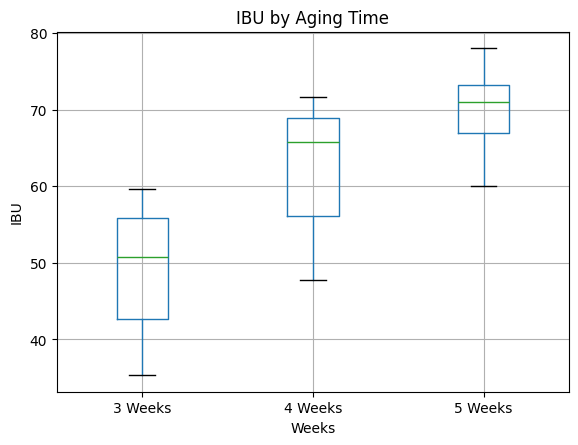

In [ ]:
plt.figure()
df.boxplot(column="IBU", by="Weeks")
plt.title("IBU by Aging Time")
plt.suptitle("")
plt.xlabel("Weeks")
plt.ylabel("IBU")
plt.show()



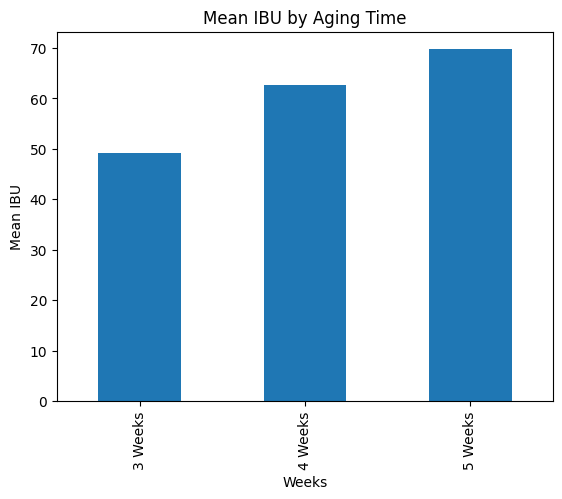

In [ ]:
means = df.groupby("Weeks")["IBU"].mean()

plt.figure()
means.plot(kind="bar")
plt.title("Mean IBU by Aging Time")
plt.xlabel("Weeks")
plt.ylabel("Mean IBU")
plt.show()


In [ ]:
model = smf.ols("IBU ~ C(Weeks)", data=df).fit()
anova_table = sm.stats.anova_lm(model, typ=2)
anova_table


,sum_sq,df,F,PR(>F)
C(Weeks),2174.83994,2.0,19.339842,0.000006
Residual,1518.12718,27.0,NaN,NaN


<Figure size 640x480 with 0 Axes>

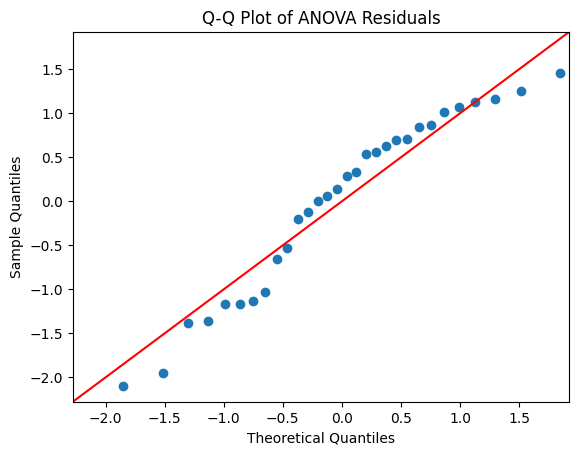

In [ ]:
residuals = model.resid

plt.figure()
sm.qqplot(residuals, line="45", fit=True)
plt.title("Q-Q Plot of ANOVA Residuals")
plt.show()


In [ ]:
stats.shapiro(residuals)


ShapiroResult(statistic=np.float64(0.9340697689829434), pvalue=np.float64(0.06303785768715889))

In [ ]:
groups = [df.loc[df["Weeks"] == w, "IBU"] for w in df["Weeks"].unique()]
stats.levene(*groups, center="median")


LeveneResult(statistic=np.float64(1.1732962841230243), pvalue=np.float64(0.3246251035079229))

In [ ]:
tukey = pairwise_tukeyhsd(endog=df["IBU"], groups=df["Weeks"], alpha=0.05)
print(tukey)


 Multiple Comparison of Means - Tukey HSD, FWER=0.05  
 group1  group2 meandiff p-adj   lower   upper  reject
------------------------------------------------------
3 Weeks 4 Weeks   13.535 0.0011  5.2205 21.8495   True
3 Weeks 5 Weeks   20.509    0.0 12.1945 28.8235   True
4 Weeks 5 Weeks    6.974 0.1131 -1.3405 15.2885  False
------------------------------------------------------
